# 08. The Hydrogen Economy

This model opens a new phase: Power-to-X. So far every sector-coupling link has moved
energy between electricity and heat. This model introduces a **third energy carrier — hydrogen** —
produced by an electrolyzer and consumed by a fixed industrial offtake, with its own dedicated
storage buffer sitting between production and demand.

The objective is to extend the Model 07 system (10 MW Solar PV + 15 MW Wind + Battery + Heat Pump +
Electric Boiler + Thermal Storage + industrial and heat demand) with a **4 MW electrolyzer**
producing hydrogen for a **constant industrial offtake**, buffered by a dedicated **hydrogen store**.

## 🛠️ System Topology
1. **Buses:** `electricity_bus`, `heat_bus` (both unchanged from Model 07), and a new `hydrogen_bus`.
2. **Generators (Source):** Solar PV (10 MW) and Wind (15 MW), unchanged.
3. **Generators (Grid, two-directional):** `Grid_Import` and `Grid_Export`, unchanged.
4. **Loads:** `Industrial_Load` and `Heat_Demand`, unchanged, plus a new constant `H2_Demand` on
   `hydrogen_bus` — no hydrogen offtake data file exists for this model, so (as with the electrical
   and heat loads before it) a flat contracted demand is set directly in code.
5. **Storage:** `Battery` and `Thermal_Storage`, unchanged, plus a new `Hydrogen_Storage` — a `Store`
   on `hydrogen_bus`, buffering the mismatch between intermittent electrolyzer production and a
   perfectly flat offtake.
6. **Links:** `Heat_Pump` and `Electric_Boiler`, unchanged, plus a new `Electrolyzer` — electricity
   in, hydrogen out, at a fixed conversion efficiency (65% on an LHV basis, roughly in line with
   commercial alkaline/PEM electrolyzers).

Just like the heat pump and boiler, the electrolyzer draws from the shared `electricity_bus`, so it
joins the same merit order automatically: solar and wind are always the cheapest electrons available,
so the solver runs the electrolyzer on renewables whenever they're there, and falls back to
`Grid_Import` only when it must — now across *three* competing electrical loads (industrial demand,
heat production, and hydrogen production) instead of two.

<img src="../assets/model_8.jpg" alt="Model 08 System Topology" width="800">


In [10]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Import custom publication-quality plotting style
sys.path.append('../')
from utils.viz_utils import set_nature_style

# Activate global styling
set_nature_style()

# Load processed data
df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

# This completely eliminates any duplicate timestamps caused by Daylight Saving Time.
perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')

# Force all three dataframes to use this clean index
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## ⚙️ Technical Parameters

All electricity, heat, and storage parameters are carried over unchanged from Model 07. Two new
entries are added: `electrolyzer` for the conversion technology, and `h2_demand` for the constant
offtake contract.


In [11]:
# Centralized dictionary for technical and economic parameters
tech_param = {
    'solar_pv': {
        'p_nom': 10.0,          # Nominal capacity of the solar PV system in MW
        'marginal_cost': 0.0    # Marginal cost of solar PV generation in $/MWh
    },
    'wind': {
        'p_nom': 15.0,          # Nominal capacity of the wind plant in MW
        'marginal_cost': 0.0    # Marginal cost of wind generation in $/MWh
    },
    'market_grid': {
        'import_p_nom': 20.0,   # Maximum import capacity from the grid
        'export_p_nom': 18.0    # Maximum export capacity to the grid
    },
    'demand': {
        'day_load_mw': 8.0,     # Electrical load during working hours (08:00-18:00)
        'night_load_mw': 4.0    # Electrical load outside working hours
    },
    'battery': {
        'p_nom': 4.0,                # Charge/discharge power rating in MW
        'max_hours': 2.0,            # Duration -> 4 MW x 2h = 8 MWh usable capacity
        'efficiency_store': 0.95,    # Charging efficiency
        'efficiency_dispatch': 0.95  # Discharging efficiency (round-trip ~ 90%)
    },
    'heat_pump': {
        'p_nom': 1.0,            # Electrical input rating in MW
        'cop': 3.5,              # Coefficient of Performance (fixed)
        'marginal_cost': 0.5     # Small O&M cost per MWh of heat output
    },
    'electric_boiler': {
        'p_nom': 5.0,            # Electrical input rating in MW
        'efficiency': 0.99,      # Resistive heating - almost no conversion loss
        'marginal_cost': 1.0     # Slightly higher O&M cost per MWh - the "last resort" for heat
    },
    'heat_demand': {
        'avg_mw': 3.0,           # Average district heating demand
        'amplitude_mw': 2.0      # Seasonal swing around the average (winter-high)
    },
    'thermal_storage': {
        'e_nom': 40.0,           # Usable energy capacity in MWh
        'standing_loss': 0.01    # Hourly self-discharge (heat loss to surroundings)
    },
    'electrolyzer': {
        'p_nom': 4.0,             # Electrical input rating in MW
        'efficiency': 0.65,       # Electricity -> hydrogen conversion (LHV basis)
        'marginal_cost': 0.0      # No variable O&M assumed
    },
    'hydrogen_storage': {
        'e_nom': 20.0,            # Usable energy capacity in MWh (H2, LHV basis)
        'standing_loss': 0.0      # Compressed H2 storage - negligible self-discharge
    },
    'h2_demand': {
        'avg_mw': 1.5             # Constant hydrogen offtake, MW (LHV basis)
    }
}


## 🏗️ Initializing the Network

A third bus, `hydrogen_bus`, joins `electricity_bus` and `heat_bus`. The electrolyzer, added later,
is the only component bridging electricity and hydrogen.


In [12]:
# Initialize a new PyPSA network
n = pypsa.Network()
n.set_snapshots(df_pv.index)

# Add all three energy-carrier buses
n.add("Bus", "electricity_bus")
n.add("Bus", "heat_bus")
n.add("Bus", "hydrogen_bus")


Index(['hydrogen_bus'], dtype='object')

## ⚡ Adding Generators and the Grid Connection

Solar, Wind, `Grid_Import`, and `Grid_Export` are added exactly as in Model 07.


In [13]:
# 1. Add the Solar PV generator
n.add("Generator",
      "Solar_PV",
      bus="electricity_bus",
      p_nom=tech_param['solar_pv']['p_nom'],
      p_max_pu=df_pv['capacity_factor'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

# 2. Add the Wind generator
n.add("Generator",
      "Wind",
      bus="electricity_bus",
      p_nom=tech_param['wind']['p_nom'],
      p_max_pu=df_wind['capacity_factor'],
      marginal_cost=tech_param['wind']['marginal_cost'])

# 3. Add the Grid Import generator (covers any shortfall)
n.add("Generator",
      "Grid_Import",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['import_p_nom'],
      marginal_cost=df_price['price'])

# 4. Add the Grid Export Market Sink (sells any surplus)
n.add("Generator",
      "Grid_Export",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['export_p_nom'],
      p_min_pu=-1.0,
      p_max_pu=0.0,
      marginal_cost=df_price['price'])


Index(['Grid_Export'], dtype='object')

## 🎯 Adding the Electrical, Heat, and Hydrogen Demands

The electrical and heat loads are unchanged from Models 05-07. The new hydrogen demand is a flat
contracted offtake — like the earlier loads, this has no data file backing it, so it's set directly
as a constant in code.


In [14]:
# Electrical load: same day/night industrial shape as Models 03-07
is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
electrical_load = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
electrical_load = pd.Series(electrical_load, index=n.snapshots)

n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=electrical_load)

# Heat load: same seasonal (winter-high) shape as Models 05-07
day_of_year = n.snapshots.dayofyear
heat_load = tech_param['heat_demand']['avg_mw'] - tech_param['heat_demand']['amplitude_mw'] * np.sin(
    (day_of_year - 80) * 2 * np.pi / 365
)
heat_load = pd.Series(np.clip(heat_load, 0.2, None), index=n.snapshots)

n.add("Load", "Heat_Demand", bus="heat_bus", p_set=heat_load)

# Hydrogen load: constant industrial offtake - no data file needed
h2_load = pd.Series(tech_param['h2_demand']['avg_mw'], index=n.snapshots)

n.add("Load", "H2_Demand", bus="hydrogen_bus", p_set=h2_load)

print(f"Electrolyzer max H2 output: {tech_param['electrolyzer']['p_nom'] * tech_param['electrolyzer']['efficiency']:.2f} MW vs. constant H2 demand: {tech_param['h2_demand']['avg_mw']:.2f} MW")


Electrolyzer max H2 output: 2.60 MW vs. constant H2 demand: 1.50 MW


## 🔋 Adding Storage, 🔗 Heat Pump, and 🔥 Boiler

`Battery`, `Thermal_Storage`, `Heat_Pump`, and `Electric_Boiler` are all added exactly as in
Model 07.


In [15]:
n.add("StorageUnit",
      "Battery",
      bus="electricity_bus",
      p_nom=tech_param['battery']['p_nom'],
      max_hours=tech_param['battery']['max_hours'],
      efficiency_store=tech_param['battery']['efficiency_store'],
      efficiency_dispatch=tech_param['battery']['efficiency_dispatch'],
      cyclic_state_of_charge=True)

n.add("Store",
      "Thermal_Storage",
      bus="heat_bus",
      e_nom=tech_param['thermal_storage']['e_nom'],
      e_cyclic=True,
      standing_loss=tech_param['thermal_storage']['standing_loss'])

n.add("Link",
      "Heat_Pump",
      bus0="electricity_bus",
      bus1="heat_bus",
      p_nom=tech_param['heat_pump']['p_nom'],
      efficiency=tech_param['heat_pump']['cop'],
      marginal_cost=tech_param['heat_pump']['marginal_cost'])

n.add("Link",
      "Electric_Boiler",
      bus0="electricity_bus",
      bus1="heat_bus",
      p_nom=tech_param['electric_boiler']['p_nom'],
      efficiency=tech_param['electric_boiler']['efficiency'],
      marginal_cost=tech_param['electric_boiler']['marginal_cost'])


Index(['Electric_Boiler'], dtype='object')

## 💧 Adding the Electrolyzer and Hydrogen Storage

The electrolyzer is structurally identical to the heat pump and boiler — a `Link` from
`electricity_bus`, but now to the new `hydrogen_bus` — scaled by its conversion efficiency instead of
a COP. `Hydrogen_Storage` is a `Store` on `hydrogen_bus`, exactly analogous to `Thermal_Storage`,
buffering the mismatch between intermittent electrolyzer output and the perfectly flat offtake
demand.


In [16]:
n.add("Link",
      "Electrolyzer",
      bus0="electricity_bus",
      bus1="hydrogen_bus",
      p_nom=tech_param['electrolyzer']['p_nom'],
      efficiency=tech_param['electrolyzer']['efficiency'],
      marginal_cost=tech_param['electrolyzer']['marginal_cost'])

n.add("Store",
      "Hydrogen_Storage",
      bus="hydrogen_bus",
      e_nom=tech_param['hydrogen_storage']['e_nom'],
      e_cyclic=True,
      standing_loss=tech_param['hydrogen_storage']['standing_loss'])


Index(['Hydrogen_Storage'], dtype='object')

## 🧠 Running the Optimization

With three coupled buses, two storage components, and three competing electrical consumers
(industrial load, heat production, and hydrogen production) all defined, the solver optimizes the
full year across every carrier simultaneously.


In [17]:
# Optimize the network dispatch using the HiGHS solver
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Net Cost, Import minus Export Revenue): €{n.objective:,.2f}")


Index(['Thermal_Storage', 'Hydrogen_Storage'], dtype='object', name='Store')
Index(['Heat_Pump', 'Electric_Boiler', 'Electrolyzer'], dtype='object', name='Link')
Index(['electricity_bus', 'heat_bus', 'hydrogen_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 20.07it/s]
INFO:linopy.io: Writing time: 2.17s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 122640 primals, 262800 duals
Objective: 2.68e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower

Solver Status: ok
Total Objective Value (Net Cost, Import minus Export Revenue): €267,605.32


## 📊 Analyzing the Results

We check that the constant hydrogen offtake is being met purely from storage buffering (rather than
requiring the electrolyzer to run flat-out, which it physically can't against a variable RE supply),
and visualize the hydrogen store's charge/discharge pattern against the electrolyzer's intermittent
output.


Hydrogen Produced:              13,140.00 MWh
Hydrogen Demand:                13,140.00 MWh
Electrolyzer Electricity Input: 20,215.38 MWh
---------------------------------------------
H2 Storage Charged:             5,242.30 MWh
H2 Storage Discharged:          5,242.30 MWh
---------------------------------------------
Hours Electrolyzer Active:      5361 / 8760
Hours Electrolyzer at Capacity: 4696


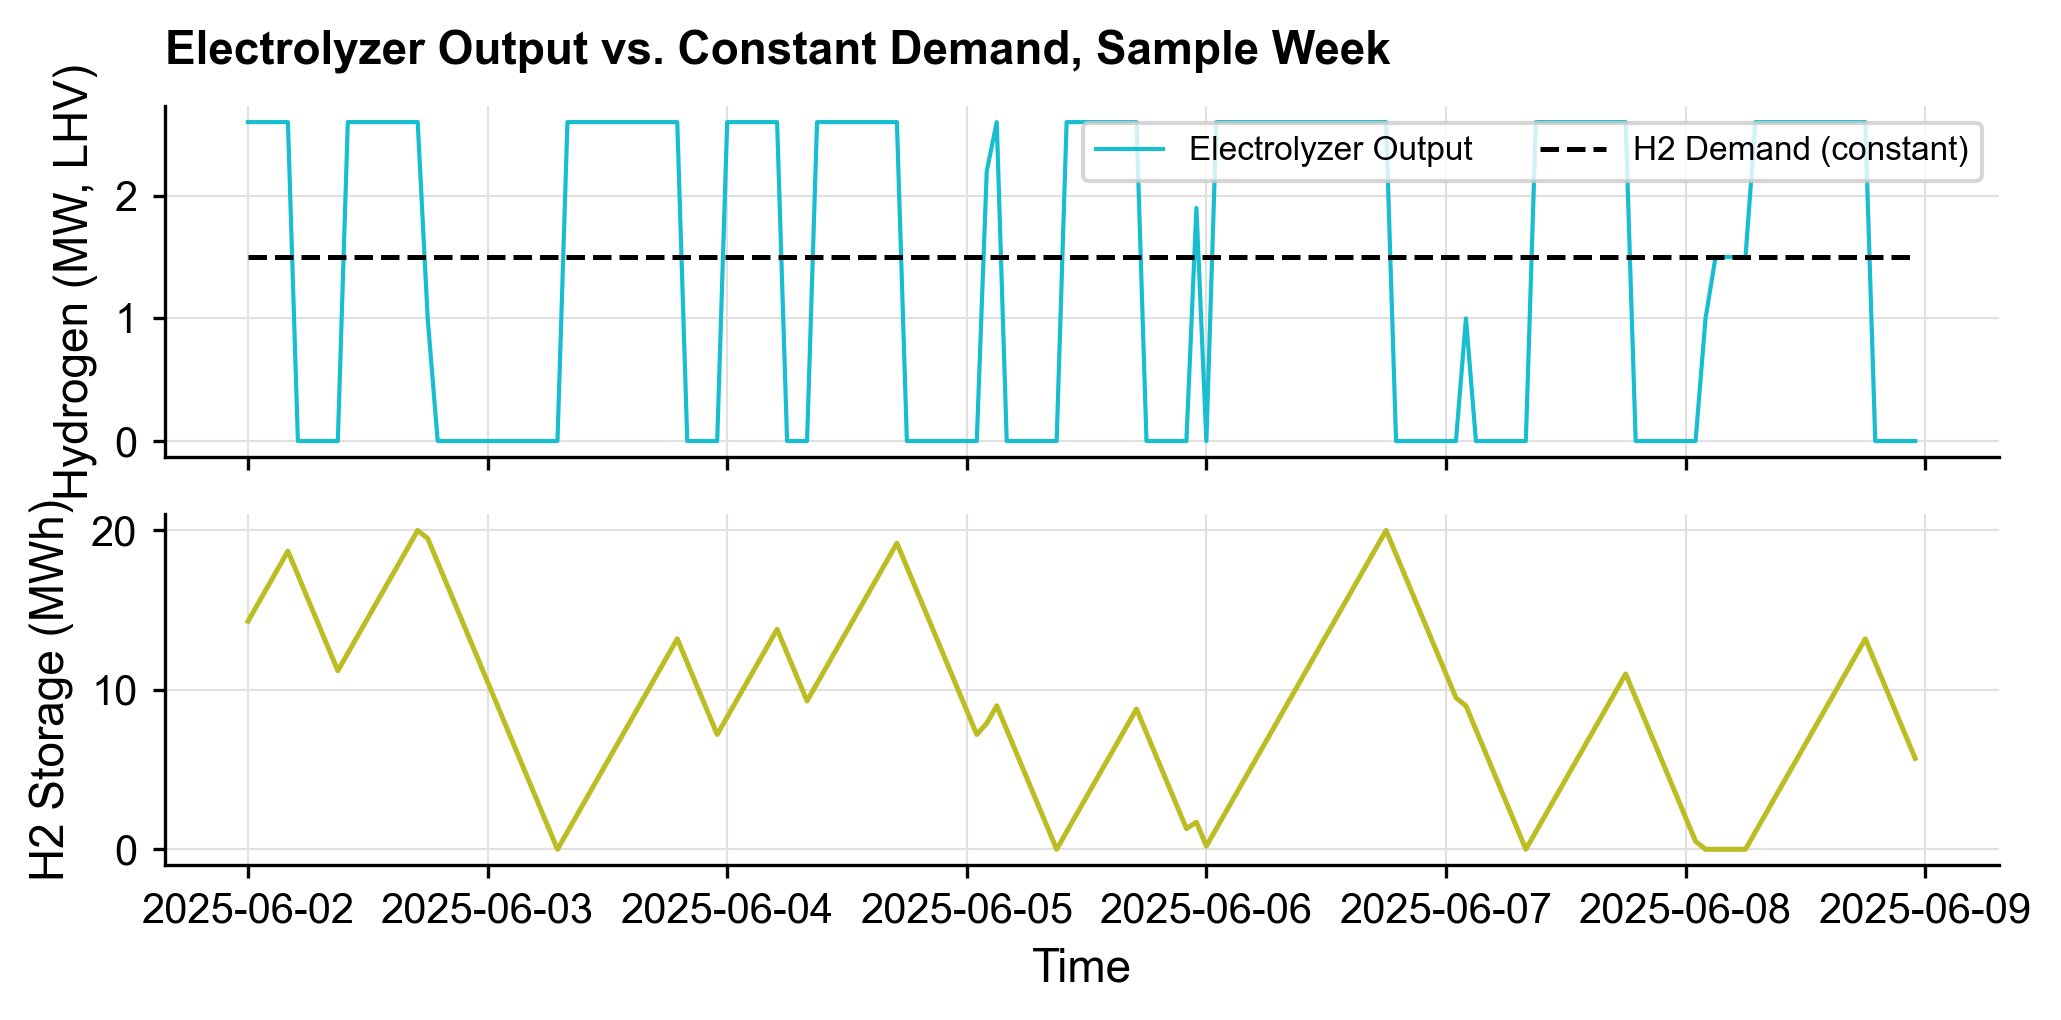

In [18]:
# Calculate Annual Totals
h2_produced_mwh = -n.links_t.p1['Electrolyzer'].sum()
h2_demand_mwh = h2_load.sum()
electrolyzer_input_mwh = n.links_t.p0['Electrolyzer'].sum()
h2_storage_charged_mwh = -n.stores_t.p['Hydrogen_Storage'].clip(upper=0).sum()
h2_storage_discharged_mwh = n.stores_t.p['Hydrogen_Storage'].clip(lower=0).sum()

hours_electrolyzer_active = (n.links_t.p0['Electrolyzer'] > 0.01).sum()
hours_electrolyzer_at_capacity = (n.links_t.p0['Electrolyzer'] >= tech_param['electrolyzer']['p_nom'] * 0.99).sum()

print(f"Hydrogen Produced:              {h2_produced_mwh:,.2f} MWh")
print(f"Hydrogen Demand:                {h2_demand_mwh:,.2f} MWh")
print(f"Electrolyzer Electricity Input: {electrolyzer_input_mwh:,.2f} MWh")
print("-" * 45)
print(f"H2 Storage Charged:             {h2_storage_charged_mwh:,.2f} MWh")
print(f"H2 Storage Discharged:          {h2_storage_discharged_mwh:,.2f} MWh")
print("-" * 45)
print(f"Hours Electrolyzer Active:      {hours_electrolyzer_active} / {len(n.snapshots)}")
print(f"Hours Electrolyzer at Capacity: {hours_electrolyzer_at_capacity}")

# Plot one representative week: electrolyzer output, constant demand, and storage level
week = (n.snapshots >= '2025-06-02') & (n.snapshots < '2025-06-09')

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(n.snapshots[week], -n.links_t.p1['Electrolyzer'][week], color='#17becf', linewidth=1.0, label='Electrolyzer Output')
ax1.plot(n.snapshots[week], h2_load[week], color='black', linewidth=1.2, linestyle='--', label='H2 Demand (constant)')
ax1.set_ylabel('Hydrogen (MW, LHV)')
ax1.set_title('Electrolyzer Output vs. Constant Demand, Sample Week', pad=10, loc='left', fontweight='bold')
ax1.legend(loc='upper right', ncol=2, fontsize=8)

ax2.plot(n.snapshots[week], n.stores_t.e['Hydrogen_Storage'][week], color='#bcbd22', linewidth=1.2)
ax2.set_ylabel('H2 Storage (MWh)')
ax2.set_xlabel('Time')

plt.tight_layout()
plt.show()
